# Parametric SLM: emulating the TOV solver across EOS parameters

This tutorial shows how to train the **SLM emulator of the TOV solver**
(`slmemulator.TOVEmulator`) on a grid of equation-of-state (EOS) parameters and
then predict mass–radius and tidal curves at *new* parameter values in a
fraction of a millisecond — no TOV solve required at prediction time.

**How it works.** For each training parameter point the emulator generates the
EOS, solves the TOV equations, and stores the log-transformed curves
$[\log R,\ \log P_c,\ \log M,\ \log k_2]$ (the *star log-extended* structure of
the SLM method, [arXiv:2411.10556](https://arxiv.org/abs/2411.10556)). The
curves are then interpolated across min–max-normalized parameter space with the
**Banach Greedy Recombination Interpolation Method** (Banach GRIM,
[arXiv:2205.07495](https://arxiv.org/abs/2205.07495)): the dense kernel
interpolant is thinned by recombination against a greedily grown set of
evaluation functionals, which is exact at the matched functionals and smooth in
between.

For a scripted version of this workflow (with accuracy/timing tables), see
`tests/testpSLM.py`.

## 1. Train the emulator

We train on a small $3\times3$ grid of the Quarkyonia EOS parameters
$(\Lambda, \kappa)$. For tutorial speed we lower the TOV integration steps to
`sol_pts=1000`; use the default `sol_pts=4000` for production runs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter

from slmemulator import TOVEmulator, quarkyonia_generator

# training grid: 3 x 3 in (lambda, kappa)
lam_grid = np.linspace(300.0, 500.0, 3)
kappa_grid = np.linspace(0.1, 0.3, 3)
train_params = np.array([(l, k) for l in lam_grid for k in kappa_grid])

emulator = TOVEmulator(
    quarkyonia_generator,           # writes an EOS file for given (lambda, kappa)
    work_dir="EOS_files/QUARKYONIA_TUTORIAL",
    param_names=["lambda", "kappa"],
    tidal=True,
    sol_pts=1000,                   # tutorial speed; default is 4000
)

emulator.train(train_params)
print(f"training data: {emulator.train_data_time_:.1f} s "
      f"({len(train_params)} TOV solves), fit: {emulator.fit_time_*1e3:.0f} ms")

Saving Quarkyonia EOS to EOS_files/QUARKYONIA_TUTORIAL/EOS_3.000000e+02_1.000000e-01.txt...
Quarkonia EOS saved to EOS_files/QUARKYONIA_TUTORIAL/EOS_3.000000e+02_1.000000e-01.txt
Loading EOS data from file:  EOS_files/QUARKYONIA_TUTORIAL/EOS_3.000000e+02_1.000000e-01.txt


Max mass:  3.0252749857214427 Radius:  15.018000656 Central pressure:  203.6862340646189
Saving Quarkyonia EOS to EOS_files/QUARKYONIA_TUTORIAL/EOS_3.000000e+02_2.000000e-01.txt...
Quarkonia EOS saved to EOS_files/QUARKYONIA_TUTORIAL/EOS_3.000000e+02_2.000000e-01.txt
Loading EOS data from file:  EOS_files/QUARKYONIA_TUTORIAL/EOS_3.000000e+02_2.000000e-01.txt


Max mass:  2.9372155946753087 Radius:  14.716468057999998 Central pressure:  218.91379204159443
Saving Quarkyonia EOS to EOS_files/QUARKYONIA_TUTORIAL/EOS_3.000000e+02_3.000000e-01.txt...
Quarkonia EOS saved to EOS_files/QUARKYONIA_TUTORIAL/EOS_3.000000e+02_3.000000e-01.txt
Loading EOS data from file:  EOS_files/QUARKYONIA_TUTORIAL/EOS_3.000000e+02_3.000000e-01.txt


Max mass:  2.8576979117825916 Radius:  14.414935459999999 Central pressure:  235.76592576319175
Saving Quarkyonia EOS to EOS_files/QUARKYONIA_TUTORIAL/EOS_4.000000e+02_1.000000e-01.txt...
Quarkonia EOS saved to EOS_files/QUARKYONIA_TUTORIAL/EOS_4.000000e+02_1.000000e-01.txt
Loading EOS data from file:  EOS_files/QUARKYONIA_TUTORIAL/EOS_4.000000e+02_1.000000e-01.txt


Max mass:  2.4498080470293084 Radius:  11.198587748 Central pressure:  616.5596406759513
Saving Quarkyonia EOS to EOS_files/QUARKYONIA_TUTORIAL/EOS_4.000000e+02_2.000000e-01.txt...
Quarkonia EOS saved to EOS_files/QUARKYONIA_TUTORIAL/EOS_4.000000e+02_2.000000e-01.txt
Loading EOS data from file:  EOS_files/QUARKYONIA_TUTORIAL/EOS_4.000000e+02_2.000000e-01.txt


Max mass:  2.42670485376447 Radius:  11.165084125999998 Central pressure:  661.1552221393977
Saving Quarkyonia EOS to EOS_files/QUARKYONIA_TUTORIAL/EOS_4.000000e+02_3.000000e-01.txt...
Quarkonia EOS saved to EOS_files/QUARKYONIA_TUTORIAL/EOS_4.000000e+02_3.000000e-01.txt
Loading EOS data from file:  EOS_files/QUARKYONIA_TUTORIAL/EOS_4.000000e+02_3.000000e-01.txt


Max mass:  2.4045985237396508 Radius:  10.964062394 Central pressure:  715.1507704952265
Saving Quarkyonia EOS to EOS_files/QUARKYONIA_TUTORIAL/EOS_5.000000e+02_1.000000e-01.txt...
Quarkonia EOS saved to EOS_files/QUARKYONIA_TUTORIAL/EOS_5.000000e+02_1.000000e-01.txt
Loading EOS data from file:  EOS_files/QUARKYONIA_TUTORIAL/EOS_5.000000e+02_1.000000e-01.txt


Max mass:  2.2286742122349668 Radius:  10.059464599999998 Central pressure:  1039.125697715724
Saving Quarkyonia EOS to EOS_files/QUARKYONIA_TUTORIAL/EOS_5.000000e+02_2.000000e-01.txt...
Quarkonia EOS saved to EOS_files/QUARKYONIA_TUTORIAL/EOS_5.000000e+02_2.000000e-01.txt
Loading EOS data from file:  EOS_files/QUARKYONIA_TUTORIAL/EOS_5.000000e+02_2.000000e-01.txt


Max mass:  2.225845497893223 Radius:  10.126471844 Central pressure:  976.1271041382221
Saving Quarkyonia EOS to EOS_files/QUARKYONIA_TUTORIAL/EOS_5.000000e+02_3.000000e-01.txt...
Quarkonia EOS saved to EOS_files/QUARKYONIA_TUTORIAL/EOS_5.000000e+02_3.000000e-01.txt
Loading EOS data from file:  EOS_files/QUARKYONIA_TUTORIAL/EOS_5.000000e+02_3.000000e-01.txt


Max mass:  2.222986024999855 Radius:  10.059464599999998 Central pressure:  1013.2704295883759
training data: 39.6 s (9 TOV solves), fit: 5 ms


## 2. Predict at new parameters and validate

`predict` maps parameters directly to the curves (radius in km, central
pressure in MeV/fm$^3$, mass in $M_\odot$, and the Love number $k_2$). We
validate against a direct TOV solve at a held-out point.

In [2]:
theta = [370.0, 0.17]     # held-out: not on the training grid

curves_emulated = emulator.predict(theta)            # instant
curves_true = emulator.solve(theta, tag="_test")     # full physics (EOS + TOV)

names = emulator.quantity_names
rel_err = np.max(np.abs(curves_emulated - curves_true) / np.abs(curves_true), axis=1)
for name, err in zip(names, rel_err):
    print(f"max relative error, {name:<18}: {err:.2e}")

Saving Quarkyonia EOS to EOS_files/QUARKYONIA_TUTORIAL/EOS_test_3.700000e+02_1.700000e-01.txt...
Quarkonia EOS saved to EOS_files/QUARKYONIA_TUTORIAL/EOS_test_3.700000e+02_1.700000e-01.txt
Loading EOS data from file:  EOS_files/QUARKYONIA_TUTORIAL/EOS_test_3.700000e+02_1.700000e-01.txt


Max mass:  2.553757920377635 Radius:  11.868660188 Central pressure:  527.8135
max relative error, Radius            : 2.21e-02
max relative error, Central Pressure  : 8.50e-02
max relative error, Mass              : 5.24e-02
max relative error, k2                : 9.11e-02


/tmp/ipykernel_55642/4257865491.py:17: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


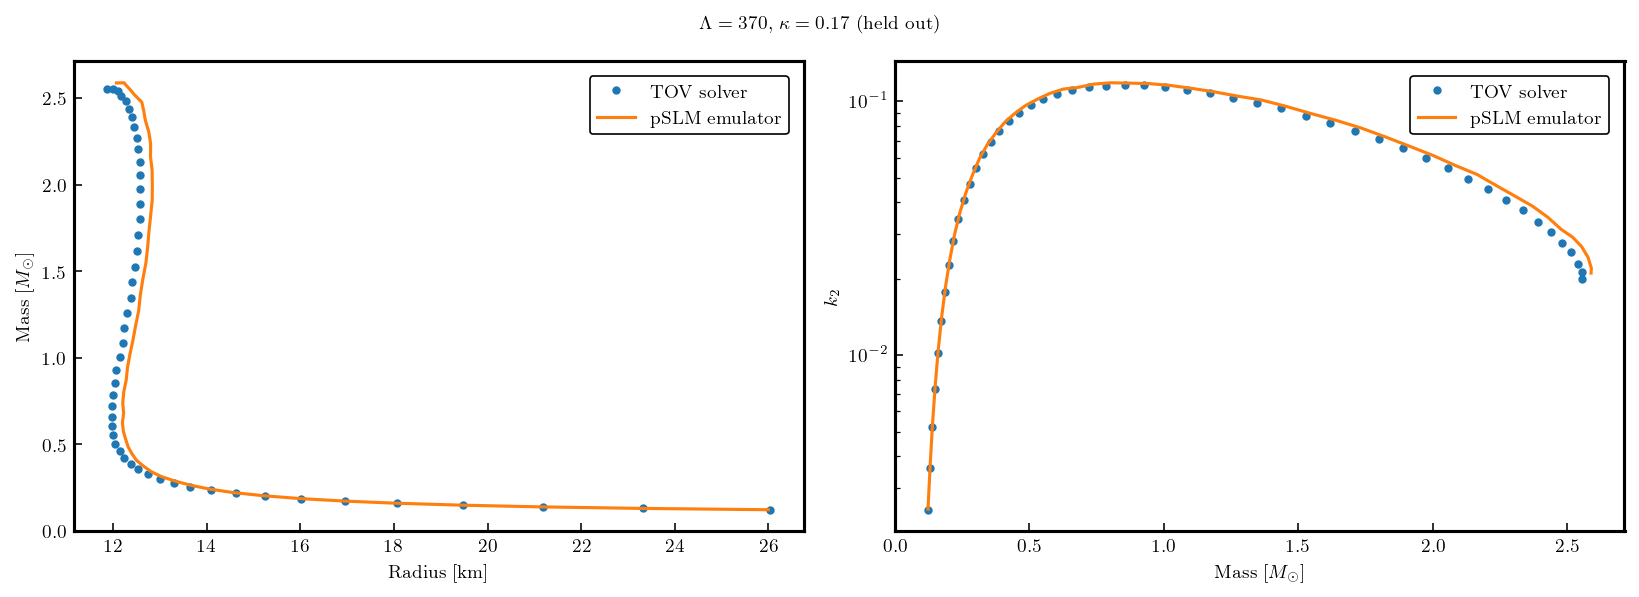

In [3]:
R_emu, Pc_emu, M_emu, k2_emu = curves_emulated
R_true, Pc_true, M_true, k2_true = curves_true

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(R_true, M_true, ".", label="TOV solver")
axes[0].plot(R_emu, M_emu, "-", label="pSLM emulator")
axes[0].set_xlabel("Radius [km]")
axes[0].set_ylabel(r"Mass [$M_\odot$]")
axes[0].legend()

axes[1].semilogy(M_true, k2_true, ".", label="TOV solver")
axes[1].semilogy(M_emu, k2_emu, "-", label="pSLM emulator")
axes[1].set_xlabel(r"Mass [$M_\odot$]")
axes[1].set_ylabel(r"$k_2$")
axes[1].legend()
fig.suptitle(rf"$\Lambda = {theta[0]:g}$, $\kappa = {theta[1]:g}$ (held out)")
fig.tight_layout()
plt.show()

## 3. Speedup

The one-time training cost is a TOV solve per grid point; after that each
prediction is a kernel evaluation.

In [4]:
t0 = perf_counter()
emulator.solve(theta, tag="_timing")
t_tov = perf_counter() - t0

t0 = perf_counter()
for _ in range(100):
    emulator.predict(theta)
t_emu = (perf_counter() - t0) / 100

print(f"TOV solver : {t_tov:.2f} s per parameter point")
print(f"emulator   : {t_emu*1e3:.3f} ms per parameter point "
      f"(~{t_tov/t_emu:,.0f}x speedup)")

Saving Quarkyonia EOS to EOS_files/QUARKYONIA_TUTORIAL/EOS_timing_3.700000e+02_1.700000e-01.txt...
Quarkonia EOS saved to EOS_files/QUARKYONIA_TUTORIAL/EOS_timing_3.700000e+02_1.700000e-01.txt
Loading EOS data from file:  EOS_files/QUARKYONIA_TUTORIAL/EOS_timing_3.700000e+02_1.700000e-01.txt


Max mass:  2.553757920377635 Radius:  11.868660188 Central pressure:  527.8135
TOV solver : 4.43 s per parameter point
emulator   : 0.010 ms per parameter point (~431,904x speedup)


## 4. Persist the trained emulator

Training is the expensive part, so save it; `load` restores the emulator
without re-solving anything.

In [5]:
emulator.save("quarkyonia_emulator.npz")
emulator_2 = TOVEmulator.load("quarkyonia_emulator.npz")
print("round-trip identical:",
      np.allclose(emulator_2.predict(theta), curves_emulated))

round-trip identical: True


## 5. SLM/DMD modes of an emulated curve

The emulated curve can be fed straight into the SLM decomposition (log-space
DMD with quadratic augmentation) to obtain modes, eigenvalues and a reduced
reconstruction — the parametric SLM (pSLM) pipeline end to end.

In [6]:
Phi, omega, eigs, b, Xdmd, S, r = emulator.slm(theta, error_threshold=1e-6)
print(f"SLM rank: {r}; reconstruction of the emulated curve uses {len(eigs)} modes")

Optimal 'r' determined: 7 (Max absolute error = 0.030320)
SLM rank: 7; reconstruction of the emulated curve uses 7 modes


## 6. File-based workflow: `ParametricSLM`

If you already have TOV data files (columns: radius, central pressure, mass,
$k_2$) computed at known parameters, `ParametricSLM` fits the same Banach-GRIM
interpolant directly on the files. Its `predict` returns the familiar DMD
component tuple, computed *from the interpolated curve*.

In [7]:
from pathlib import Path
from slmemulator import ParametricSLM

# write the training curves as MR files (as tests/testSLM.py produces)
mr_dir = Path("TOV_data/QUARKYONIA_TUTORIAL")
mr_dir.mkdir(parents=True, exist_ok=True)
file_list = []
for p, X_log in zip(emulator.train_params, emulator.train_curves_log):
    f = mr_dir / f"MR_{p[0]:.2e}_{p[1]:.2e}.txt"
    np.savetxt(f, np.exp(X_log).T)
    file_list.append(f.name)

pslm = ParametricSLM(file_list, filePath=mr_dir, tidal=True)   # params parsed
pslm.fit()                                                     # from file names

Phi, omega, eigs, b, Xdmd, t = pslm.predict(theta)
print("predicted curve matrix:", Xdmd.shape, "| physical curves: np.exp(Xdmd.real)")

Optimal 'r' determined: 7 (Max absolute error = 0.030320)
predicted curve matrix: (4, 50) | physical curves: np.exp(Xdmd.real)


## Practical notes

* **Grid density matters.** Two points per parameter (grid corners) cannot
  emulate the interior when the curves vary strongly — for Quarkyonia use at
  least 4 points per parameter (midpoint errors then drop to the few-percent
  level, with $k_2$ the hardest quantity). Validate with held-out points, e.g.
  via `python tests/testpSLM.py`.
* **Centering.** The interpolant works on deviations from the mean training
  curve (`center=True` internally), so quantities that barely vary across the
  training set are reproduced (nearly) exactly.
* **Interpolation method.** `BanachGRIMInterpolator.fit` uses the Banach GRIM
  algorithm (`method="grim"`) by default; `method="pgreedy"` gives f·P-greedy
  kernel interpolation, which is faster for very large snapshot sets. At tight
  tolerance both reproduce the dense kernel interpolant.
* **Tolerances.** For the emulator, `tol` is the maximum entry-wise training
  residual in log space; the default `1e-12` keeps full interpolation accuracy.
